# Multilayer Perceptron
### Definition
The Multilayer Perceptron is a type of foundational neural network that connects different "layers" of neurons together. It consists of an input layer, where data will be input, and an output layer, which consists of the Multilayer perceptron's predictions. Between the input and output layers, there are $k >= 0$ "hidden layers", that each consist of neurons. Let $n_0, \dots, n_{k+2}$ be the number of neurons in each layer. Furthermore, the multilayer perceptron neurons act similarily to the Logistic Regression neurons, using the logistic function as the activation function:

$$
\sigma(z) = \frac{1}{1+e^{-x}}
$$

Now, we will explain the different components of the algorithm. 
- Let $w_0, \dots, w_{k+1}$ be the weights of each layer, where the dimensions of $w_i$ are $(n_i, n_{i+1})$.
- Let $b_0, \dots, b_{k+1}$ be the biases for each layer, where the dimensions of $b_i$ are $(n_{i+1}, 1)$.
- Let $X$ be the input data, where the dimensions are $n_0$.
- Let $\hat{y}$ be the predicted output data, where the dimensions are $n_{k+2}$.
- Let $y$ be the true output data, where the dimensions are $n_{k+2}$.
- Let $\alpha$ be the learning rate of the training.

### Feed Forward

The feed forward algorithm is how the Multilayer Perceptron makes its predictions. Given input data $X$, it makes a prediction $\hat{y}$.

1. First, we set $a_0 = X$ and let $i = 0$.
2. Now, we let $z_i = w_iX + b_i$.
3. Let $a_{i+1} = \sigma(z_i)$
4. Increment $i$ by one, and repeat until $i = k+2$.
5. Return $\hat{y} = a_{k+2}$.

### Backpropagation

Once we feed a set of training data forward and learn the prediction, we need a way to apply the gradient descent algorithm to minimize the training cost. However, this is not as straightforward as it was with single neurons, as we now have many layers, each with many neurons, to think about. The way that we can update the weights and biases to reduce the gradient is via backpropagation.

1. First, calculate the gradient of the cost function for the final layer: $\nabla_a C = a_{k+2} - y$.
2. Now, calculate the error of the final layer: $\delta^{k+2} = \nabla_a C * \sigma'(z^{k+2})$
3. Next, calculate $\delta^j = \left((w^{(j+1)})^T \delta^{j+1} * \sigma'(z^{k+2}) \right)$ for $j = k,\dots,0$
4. Finally, we update each weight and bias by layer with the corresponding $\delta^j$ terms, $w^j = w^j - \eta \delta^j (a^{j-1})^T$ and $b^j = b^j - \eta \delta^j$ for $j = k+1, \dots, 0$

### Advantages
- Allows nonlinear classification
- Extra hidden layers create the ability to interpret difficult data (e.g. image classification)
### Disadvantages
- Slow to train in comparison to simpler models
- For many datasets, unnecessary for accurate classification

# Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import random

import struct

sns.set_theme()

# Implementation

In [ ]:
def sigmoid(x):
    return 1/(1 + np.exp(-x))

def derivative_sigmoid(x):
    return sigmoid(x) * (1.0-sigmoid(x))

In [ ]:
class MultilayerPerceptron():
    def __init__(self, _layer_counts, _activation_function, _activation_function_derivative):
        # layer_counts is a list of the number of neurons to place in each hidden layer. The length
        # of layer_counts indicates how many hidden layers there are.
        self.layer_counts = _layer_counts
        self.activation_function = _activation_function
        self.activation_function_derivative = _activation_function_derivative

    def train(self, X, y, possible_outputs, eta = 0.1, epochs = 1000):
        # first extract dimensional information
        self.dim = X.shape[0]
        self.rows, self.cols = X.shape[1], X.shape[2]
        self.weights = [] # list of np matrices
        self.bias = [] # list of np arrays

        # first layer neurons are just the values of the image, no neurons necessary

        all_layer_counts = [self.rows*self.cols]
        all_layer_counts.extend(self.layer_counts)
        all_layer_counts.append(possible_outputs)
        
        activations = []
        z_vals = []
        error_vals = []

        self.n = len(all_layer_counts)
        self.batch_size = 100 # set batch size to be a divisor of the training data length

        # initialize empty weights, biases, z_vals, activations, and error_vals
        for i in range(self.n-1):
            # create neuron layer
            num_weights_per_neuron = all_layer_counts[i]
            num_neurons = all_layer_counts[i+1]
            self.weights.append(np.random.randn(num_weights_per_neuron, num_neurons)*np.sqrt(1/num_weights_per_neuron))
            self.bias.append(np.random.randn(num_neurons, 1)*1/num_weights_per_neuron)
        for i in range(self.n):
            z_vals.append(np.empty((self.batch_size, all_layer_counts[i])))
            activations.append(np.empty((self.batch_size, all_layer_counts[i])))
            error_vals.append(np.empty((self.batch_size, all_layer_counts[i])))
        
        current_loc = 0
        i = 0
        errors = np.empty((epochs, possible_outputs))
        while i < epochs:
            # first create batch
            X_batch = X[current_loc:current_loc+self.batch_size, :, :].reshape(self.batch_size, -1) # batch size by rows*cols matrix
            y_batch = y[current_loc:current_loc+self.batch_size, :] # batch size by possible_outputs matrix
            current_loc += self.batch_size
            if current_loc >= self.dim:
                current_loc = 0
            
            # then, feed forward
            activations[0] = X_batch
            for j in range(self.n-1):
                z_val = np.dot(self.weights[j].T, activations[j].T).T + self.bias[j].T
                activation = self.activation_function(z_val)
                z_vals[j+1] = z_val
                activations[j+1] = activation

            # calculate final error_vals
            grad_C = 1/self.batch_size * (activations[-1] - y_batch) # dimension batch_size by possible_outputs
            z_deriv = self.activation_function_derivative(z_vals[-1])
            error_vals[-1] = grad_C * z_deriv # needs to be batch_size by possible_outputs

            # then backpropagate
            for j in range(self.n-2, 0, -1):
                error_leftside = np.dot(self.weights[j], error_vals[j+1].T).T
                error_val = error_leftside * self.activation_function_derivative(z_vals[j])
                error_vals[j] = error_val

            # finally adjust weights and biases
            for j in range(self.n-1, 0, -1):
                self.weights[j-1] = self.weights[j-1] - eta*np.dot(error_vals[j].T, (activations[j-1])).T
                self.bias[j-1] = self.bias[j-1] - eta*np.sum(error_vals[j].T, axis=1, keepdims=True)
            errors[i, :] = self.cost(y_batch, activations[-1])
            i += 1
        return errors

    def cost(self, y, y_hats):
        return 1/(2*self.batch_size) * np.sum((y-y_hats)**2, axis=0)

    def feed_forward(self, X):
        activation = X
        for j in range(self.n-1):
            z_val = np.dot(self.weights[j].T, activation.T).T + self.bias[j].T
            activation = self.activation_function(z_val)
        return activation

# Number Data
## Data Preprocessing

Now, read in and process MNIST number dataset

In [4]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/"

train_labels_path = data_dir + "MNIST-Dataset/train-labels.idx1-ubyte"
train_images_path = data_dir + "MNIST-Dataset/train-images.idx3-ubyte"
test_labels_path = data_dir + "MNIST-Dataset/t10k-labels.idx1-ubyte"
test_images_path = data_dir + "MNIST-Dataset/t10k-images.idx3-ubyte"

def read_labels(labels_path):
    with open(labels_path, "rb") as file:
        magic, size = struct.unpack(">II", file.read(8))
        labels = np.frombuffer(file.read(), dtype=np.uint8)
    return labels

def read_images(images_path):
    with open(images_path, "rb") as file:
        magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
        image_data = np.frombuffer(file.read(), dtype=np.uint8)
        final_image_data = np.empty((size, rows, cols), dtype=np.uint8)
        for i in range(size):
            img = image_data[i*rows*cols:(i+1)*rows*cols].reshape(rows, cols)
            final_image_data[i, :, :] = img
        return final_image_data
train_labels = read_labels(train_labels_path)
train_images = read_images(train_images_path)
test_labels = read_labels(test_labels_path)
test_images = read_images(test_images_path)

Show image to test:

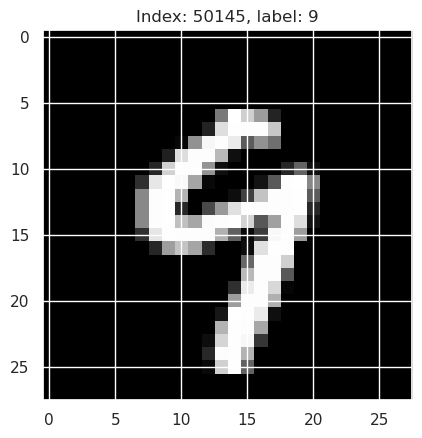

In [5]:
def show_image(images, labels, index):
    plt.imshow(images[index, :, :], cmap=plt.cm.gray)
    plt.title(f"Index: {index}, label: {labels[index]}")
    plt.show()

show_image(train_images, train_labels, 50145)

Finally, normalize data and one-hot encode y data to align with output neurons

In [6]:
X = train_images / 255.0
y = np.zeros((len(train_labels), 10))
for i in range(len(train_labels)):
    label = train_labels[i]
    y[i, label] = 1.0

Now, train on the dataset with two hidden layers, each with 16 neurons:

In [9]:
nn = MultilayerPerceptron([16, 16], sigmoid, derivative_sigmoid)
errors = nn.train(X, y, 10, eta = 0.5, epochs=10000)

Now, prep testing data:

In [ ]:
X_test = test_images / 255.0
y_test = np.zeros((len(test_labels), 10))
for i in range(len(test_labels)):
    label = test_labels[i]
    y_test[i, label] = 1.0


Now, show testing error:

In [16]:
y_hat_test = nn.feed_forward(X_test.reshape(10000, -1))
y_argmax = np.argmax(y, axis=1)
results = sum(1 if y_data == y_hat_data else 0 for (y_data, y_hat_data) in zip(np.argmax(y_test, axis=1), np.argmax(y_hat_test, axis=1)))
print(results / len(y_test))

0.929


Pretty good!

## Data Analysis

First, plot error over time with 0, 1, 2, and 3 hidden layers:

(0.001, 0.2)

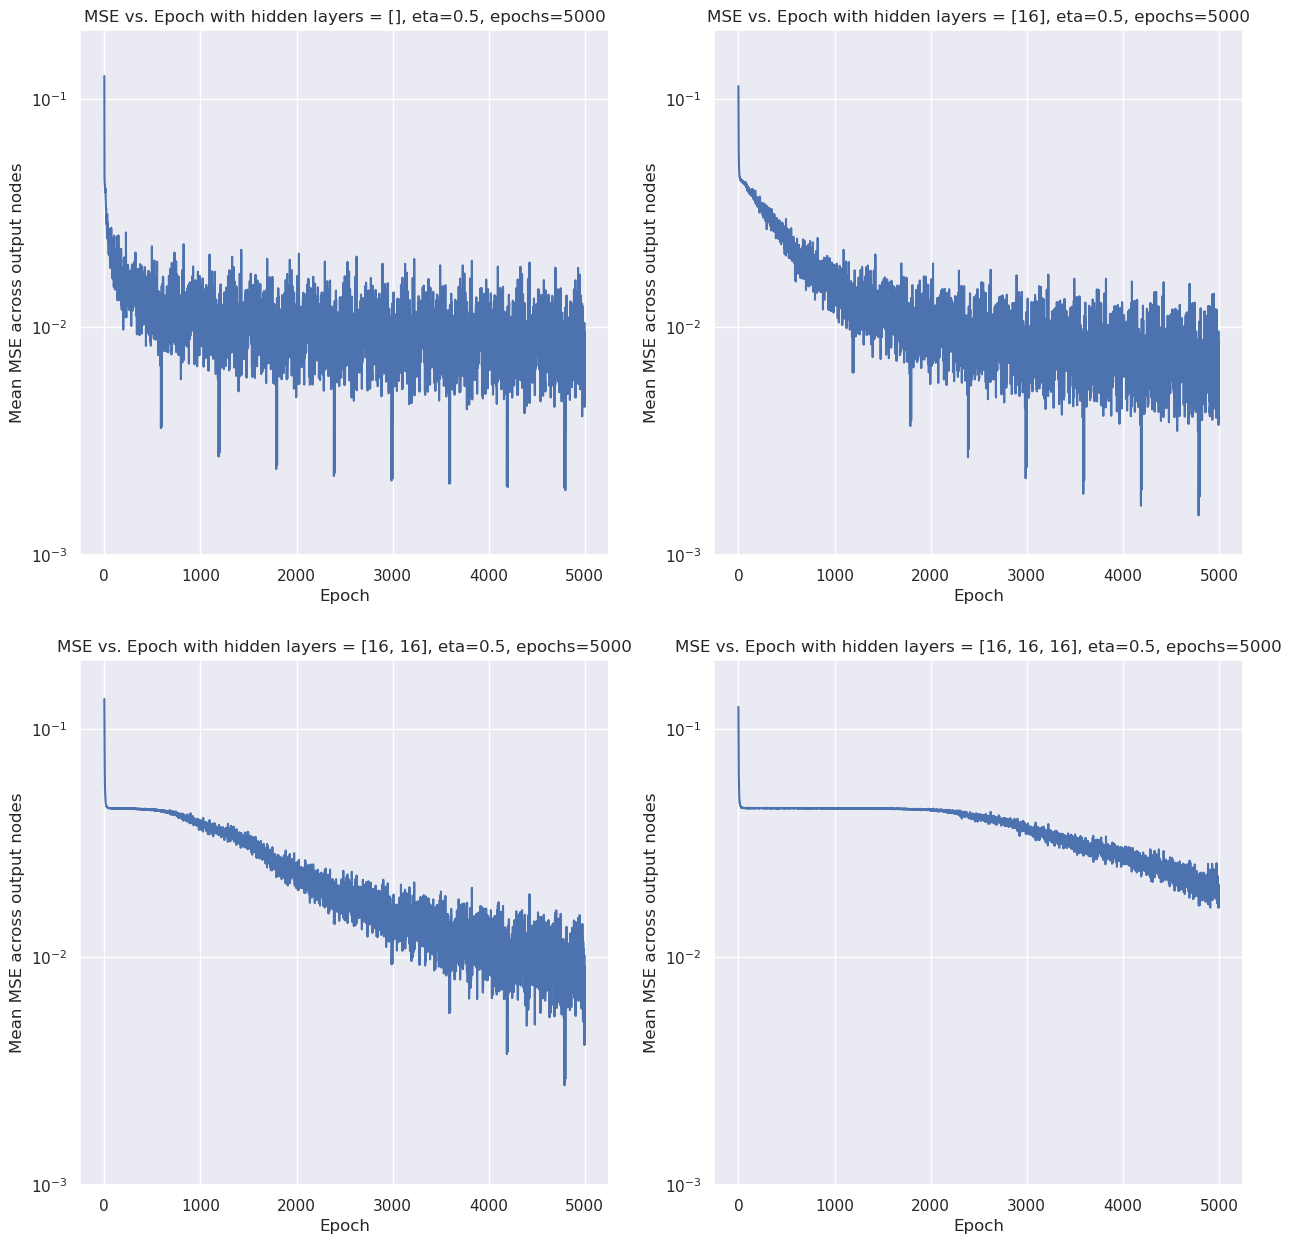

In [12]:
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
# find average error at different layer counts
hidden_layers_1 = []
eta_1 = 0.5
epochs_1 = 5000
nn_1 = MultilayerPerceptron(hidden_layers_1, sigmoid, derivative_sigmoid)
errors_1 = nn_1.train(X, y, 10, eta = eta_1, epochs=epochs_1)
mean_errors_1 = np.mean(errors_1, axis=1)
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Mean MSE across output nodes")
axs[0, 0].set_title(f"MSE vs. Epoch with hidden layers = {hidden_layers_1}, eta={eta_1}, epochs={epochs_1}")
axs[0, 0].semilogy(mean_errors_1)
axs[0, 0].set_ylim([1e-3, 2e-1])

hidden_layers_2 = [16]
eta_2 = 0.5
epochs_2 = 5000
nn_2 = MultilayerPerceptron(hidden_layers_2, sigmoid, derivative_sigmoid)
errors_2 = nn_2.train(X, y, 10, eta = eta_2, epochs=epochs_2)
mean_errors_2 = np.mean(errors_2, axis=1)
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Mean MSE across output nodes")
axs[0, 1].set_title(f"MSE vs. Epoch with hidden layers = {hidden_layers_2}, eta={eta_2}, epochs={epochs_2}")
axs[0, 1].semilogy(mean_errors_2)
axs[0, 1].set_ylim([1e-3, 2e-1])

hidden_layers_3 = [16, 16]
eta_3 = 0.5
epochs_3 = 5000
nn_3 = MultilayerPerceptron(hidden_layers_3, sigmoid, derivative_sigmoid)
errors_3 = nn_3.train(X, y, 10, eta = eta_3, epochs=epochs_3)
mean_errors_3 = np.mean(errors_3, axis=1)
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Mean MSE across output nodes")
axs[1, 0].set_title(f"MSE vs. Epoch with hidden layers = {hidden_layers_3}, eta={eta_3}, epochs={epochs_3}")
axs[1, 0].semilogy(mean_errors_3)
axs[1, 0].set_ylim([1e-3, 2e-1])

hidden_layers_4 = [16, 16, 16]
eta_4 = 0.5
epochs_4 = 5000
nn_4 = MultilayerPerceptron(hidden_layers_4, sigmoid, derivative_sigmoid)
errors_4 = nn_4.train(X, y, 10, eta = eta_4, epochs=epochs_4)
mean_errors_4 = np.mean(errors_4, axis=1)
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Mean MSE across output nodes")
axs[1, 1].set_title(f"MSE vs. Epoch with hidden layers = {hidden_layers_4}, eta={eta_4}, epochs={epochs_4}")
axs[1, 1].semilogy(mean_errors_4)
axs[1, 1].set_ylim([1e-3, 2e-1])

Here, we can see that more hidden layers makes the error take longer to start converging after hitting an initial asymptote.

Now, we vary the learning rates:

(0.001, 0.2)

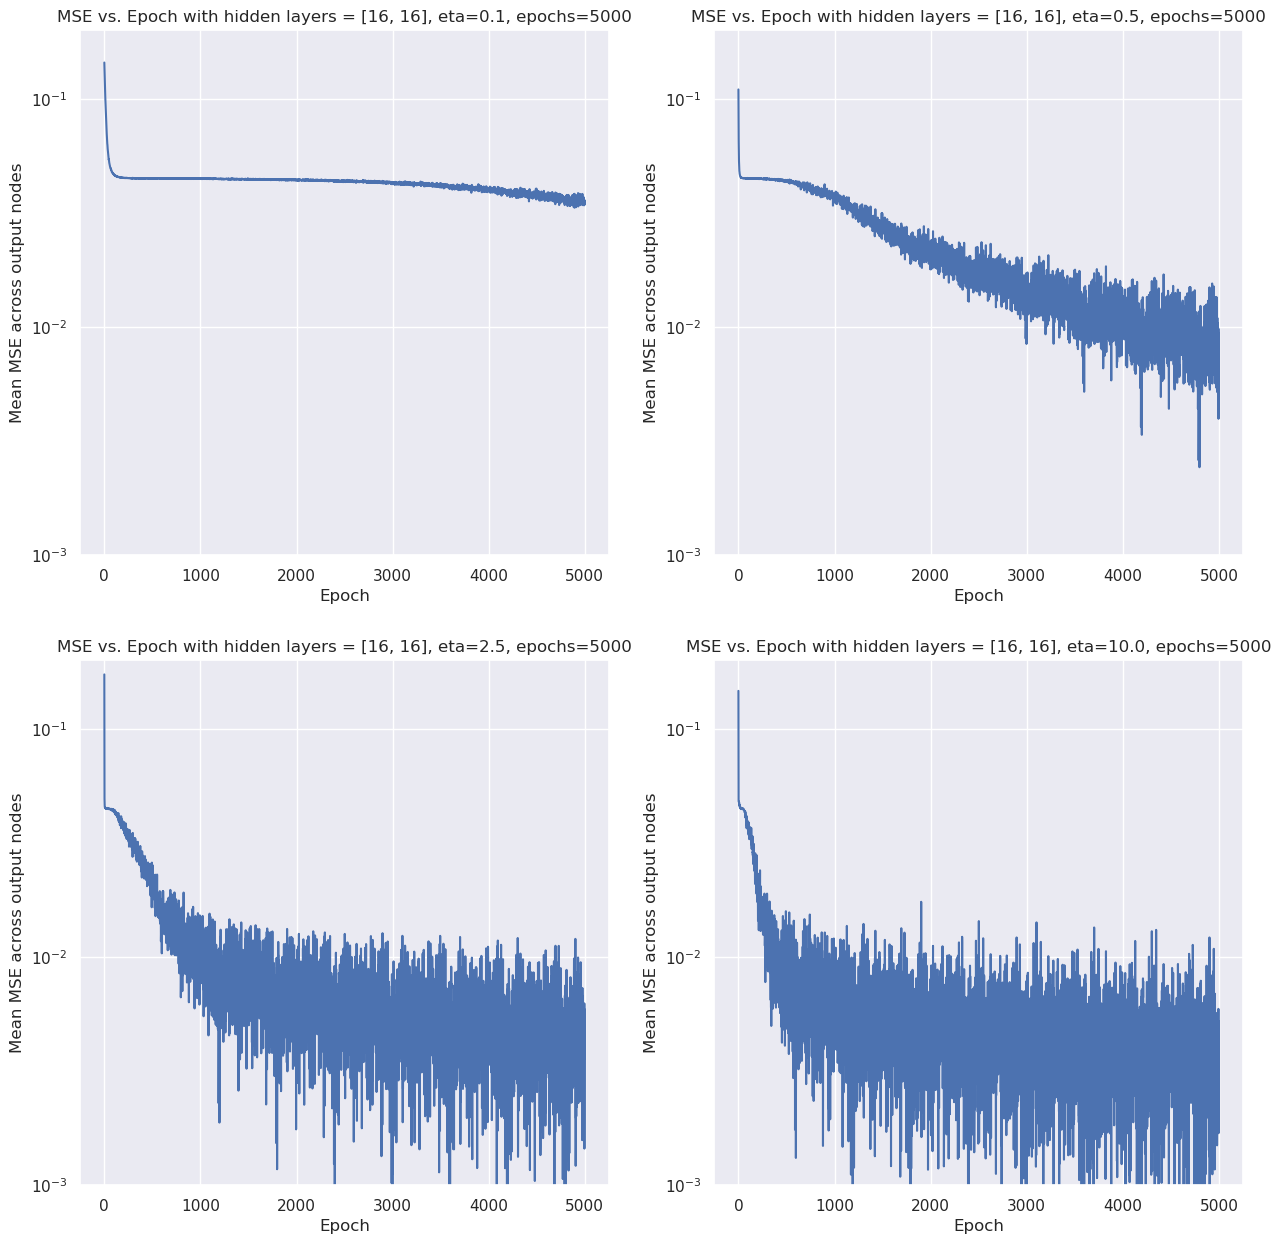

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
# find average error at different layer counts
hidden_layers_1 = [16, 16]
eta_1 = 0.1
epochs_1 = 5000
nn_1 = MultilayerPerceptron(hidden_layers_1, sigmoid, derivative_sigmoid)
errors_1 = nn_1.train(X, y, 10, eta = eta_1, epochs=epochs_1)
mean_errors_1 = np.mean(errors_1, axis=1)
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Mean MSE across output nodes")
axs[0, 0].set_title(f"MSE vs. Epoch with hidden layers = {hidden_layers_1}, eta={eta_1}, epochs={epochs_1}")
axs[0, 0].semilogy(mean_errors_1)
axs[0, 0].set_ylim([1e-3, 2e-1])

hidden_layers_2 = [16, 16]
eta_2 = 0.5
epochs_2 = 5000
nn_2 = MultilayerPerceptron(hidden_layers_2, sigmoid, derivative_sigmoid)
errors_2 = nn_2.train(X, y, 10, eta = eta_2, epochs=epochs_2)
mean_errors_2 = np.mean(errors_2, axis=1)
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Mean MSE across output nodes")
axs[0, 1].set_title(f"MSE vs. Epoch with hidden layers = {hidden_layers_2}, eta={eta_2}, epochs={epochs_2}")
axs[0, 1].semilogy(mean_errors_2)
axs[0, 1].set_ylim([1e-3, 2e-1])

hidden_layers_3 = [16, 16]
eta_3 = 2.5
epochs_3 = 5000
nn_3 = MultilayerPerceptron(hidden_layers_3, sigmoid, derivative_sigmoid)
errors_3 = nn_3.train(X, y, 10, eta = eta_3, epochs=epochs_3)
mean_errors_3 = np.mean(errors_3, axis=1)
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Mean MSE across output nodes")
axs[1, 0].set_title(f"MSE vs. Epoch with hidden layers = {hidden_layers_3}, eta={eta_3}, epochs={epochs_3}")
axs[1, 0].semilogy(mean_errors_3)
axs[1, 0].set_ylim([1e-3, 2e-1])

hidden_layers_4 = [16, 16]
eta_4 = 10.0
epochs_4 = 5000
nn_4 = MultilayerPerceptron(hidden_layers_4, sigmoid, derivative_sigmoid)
errors_4 = nn_4.train(X, y, 10, eta = eta_4, epochs=epochs_4)
mean_errors_4 = np.mean(errors_4, axis=1)
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Mean MSE across output nodes")
axs[1, 1].set_title(f"MSE vs. Epoch with hidden layers = {hidden_layers_4}, eta={eta_4}, epochs={epochs_4}")
axs[1, 1].semilogy(mean_errors_4)
axs[1, 1].set_ylim([1e-3, 2e-1])

Here, we can see that a high learning rate is necessary to get past the initial asymptote, but when the learning rate is high enough, the gradient descent correction can often overcorrect the data, which leads to significant variance in the MSE by epoch.

Now, we display some of the images in the test data that do not align with the training data:

In [14]:
def display_images(y_hat_test, y_test, n, m, show_mismatch=False):
    y_test_argmax = np.argmax(y_test, axis=1)
    y_hat_test_argmax = np.argmax(y_hat_test, axis=1)
    if show_mismatch:
        results = [i for i in range(len(y_test)) if y_test_argmax[i] != y_hat_test_argmax[i]]
    else:
        results = [i for i in range(len(y_test))]
        # results = [y_data for y_data in np.argmax(y_test, axis=1)]
    
    items = np.array(random.sample(results, k=n*m)).reshape(n, m)
    
    fig, axs = plt.subplots(n, m, figsize = (5*n, 5*m))
    for i in range(n):
        for j in range(m):
            # first pick n by m items from test data:
            item = items[i, j]
            axs[i, j].set_title(f"Test item={item} label={y_hat_test_argmax[item]} goal={y_test_argmax[item]}")
            axs[i, j].imshow(test_images[item, :, :], cmap=plt.cm.gray)


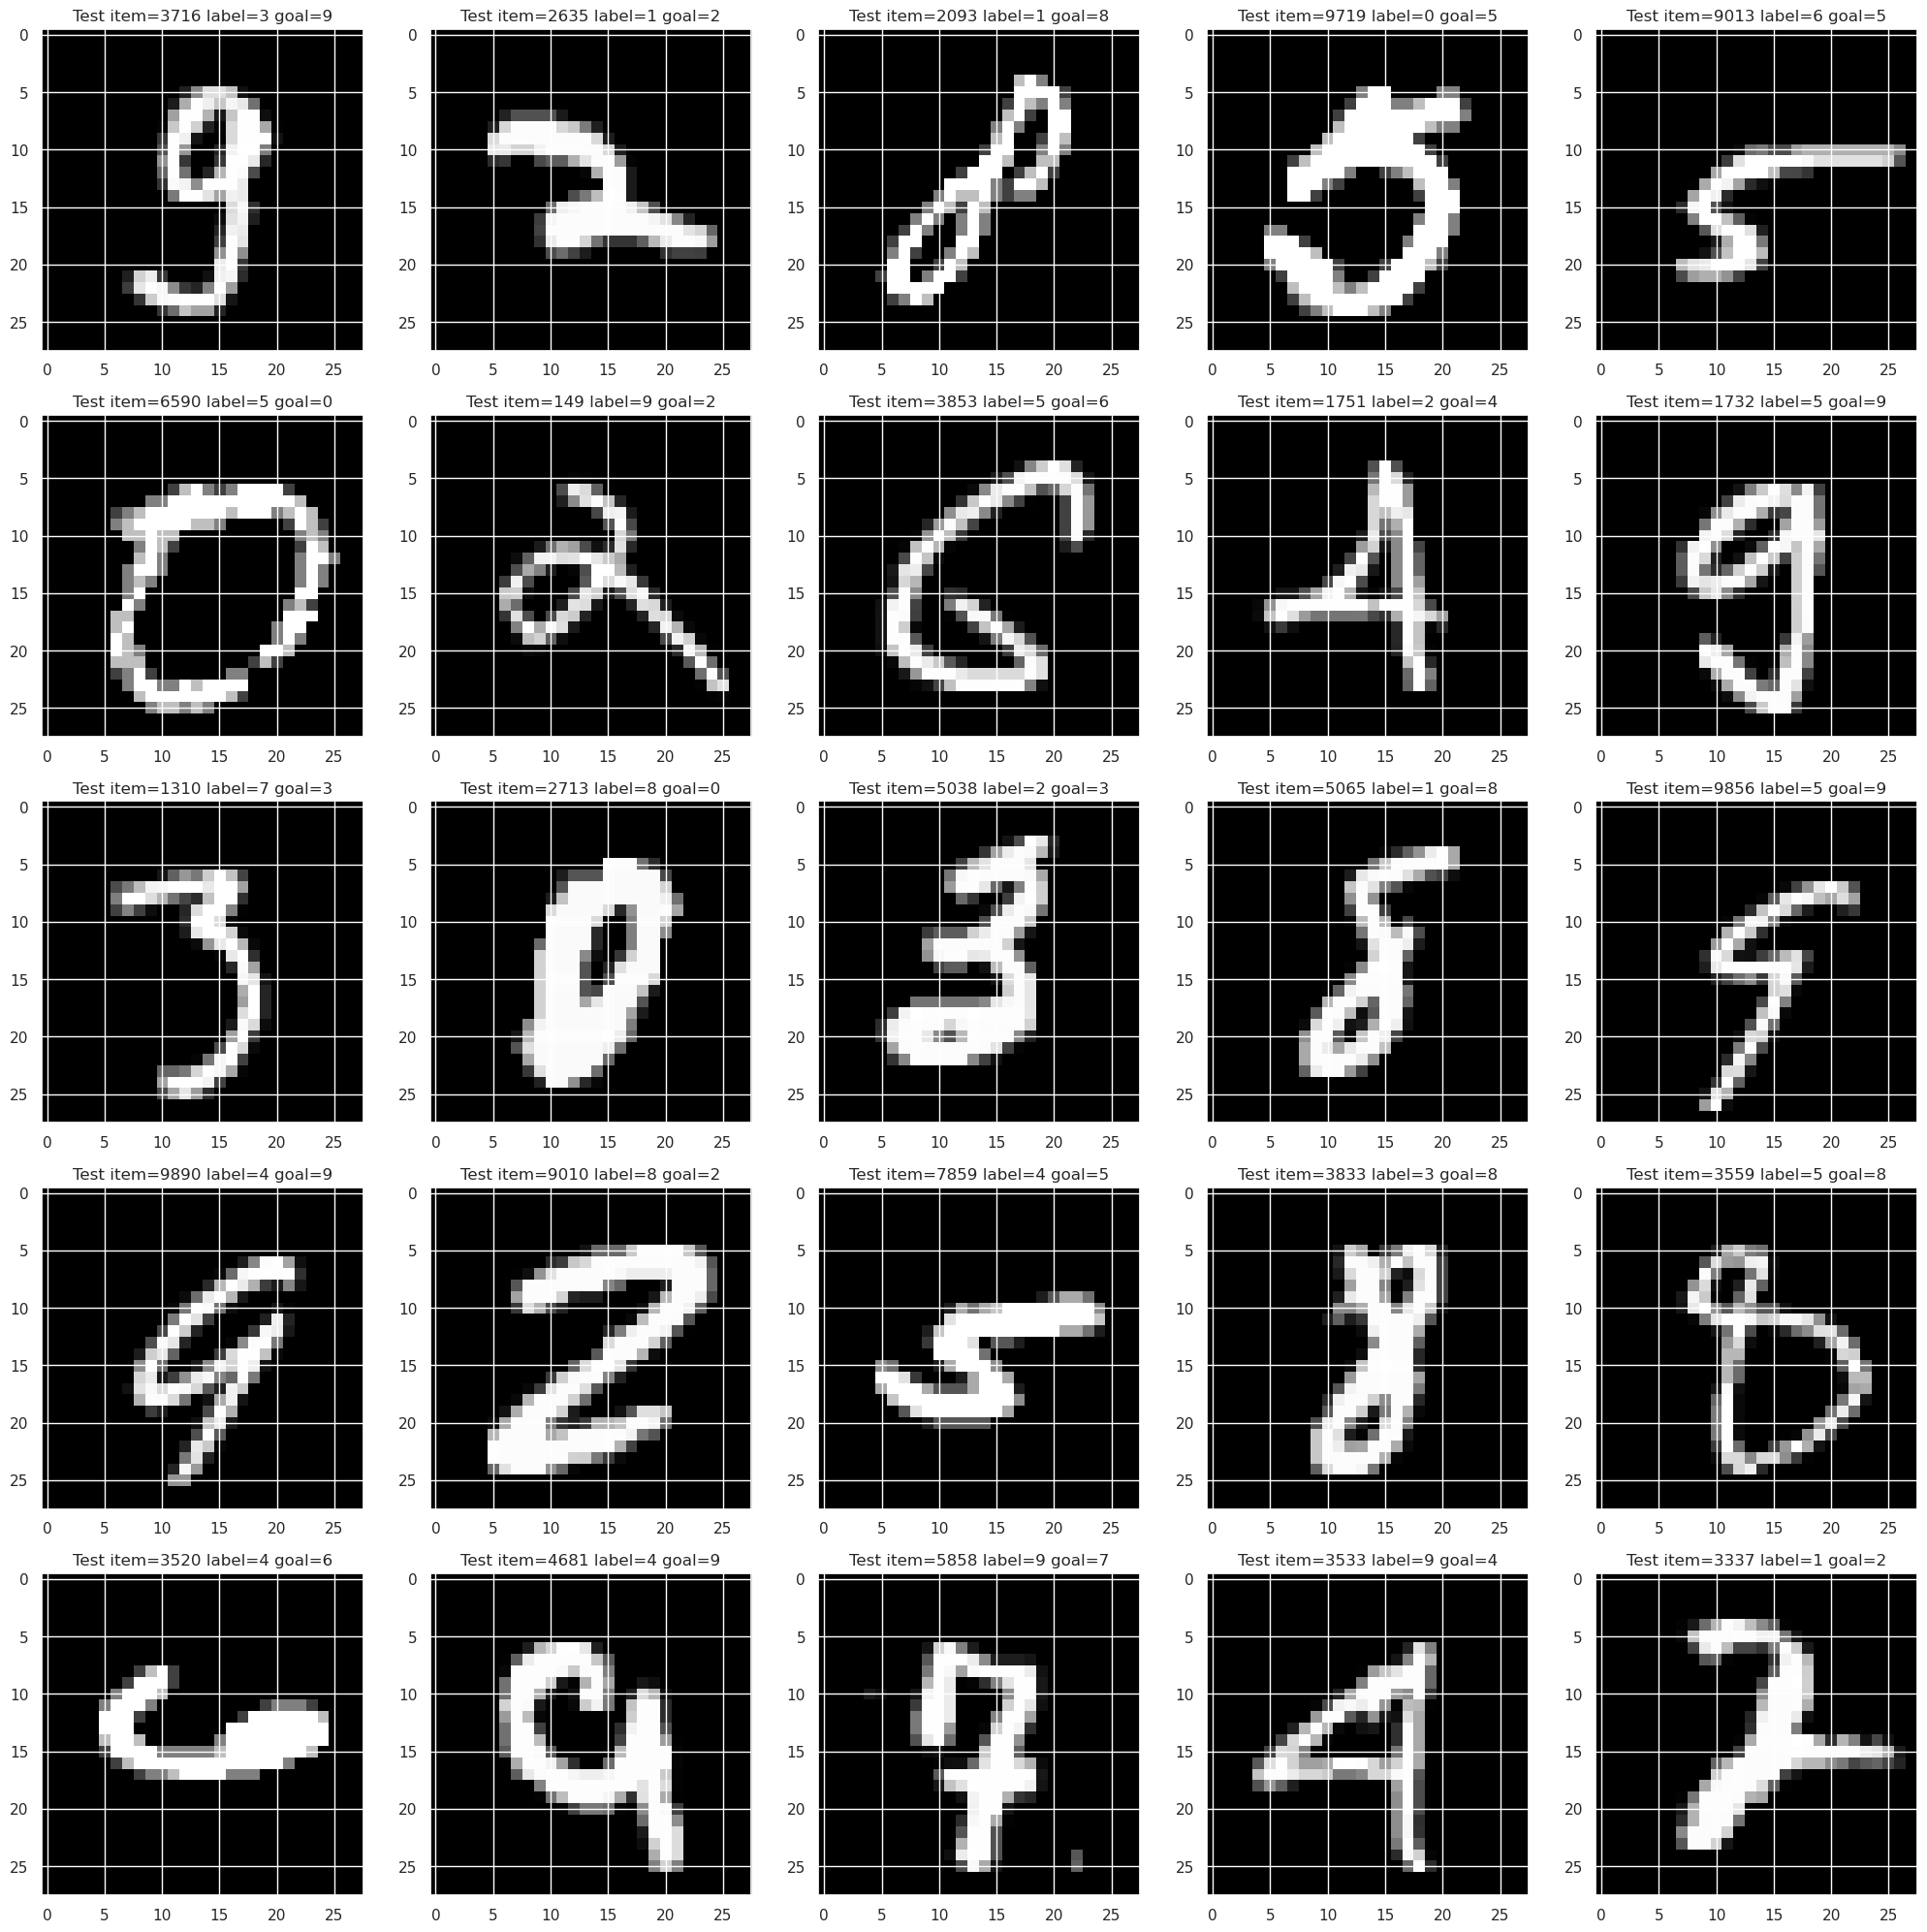

In [15]:
y_hat_test = nn.feed_forward(X_test.reshape(10000, -1))

display_images(y_hat_test, y_test, 5, 5, show_mismatch=True)

# Fashion Data
## Data Preprocessing
Now select fashion data:

In [22]:
data_dir = "/home/patrick/Projects/DataScienceAndMachineLearning/Data/"

train_labels_path = data_dir + "MNIST-Fashion-Dataset/train-labels-idx1-ubyte"
train_images_path = data_dir + "MNIST-Fashion-Dataset/train-images-idx3-ubyte"
test_labels_path = data_dir + "MNIST-Fashion-Dataset/t10k-labels-idx1-ubyte"
test_images_path = data_dir + "MNIST-Fashion-Dataset/t10k-images-idx3-ubyte"

train_labels = read_labels(train_labels_path)
train_images = read_images(train_images_path)
test_labels = read_labels(test_labels_path)
test_images = read_images(test_images_path)

label_to_name_map = {
    0: "T-shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankel boot"
}

Create testing and training data:

In [23]:
X = train_images / 255.0
y = np.zeros((len(train_labels), 10))
for i in range(len(train_labels)):
    label = train_labels[i]
    y[i, label] = 1.0

X_test = test_images / 255.0
y_test = np.zeros((len(test_labels), 10))
for i in range(len(test_labels)):
    label = test_labels[i]
    y_test[i, label] = 1.0

And train the model on this new data:

In [24]:
nn = MultilayerPerceptron([16, 16], sigmoid, derivative_sigmoid)
errors = nn.train(X, y, 10, eta = 0.5, epochs=10000)

Finally, print testing error:

In [25]:
y_hat_test = nn.feed_forward(X_test.reshape(10000, -1))
y_argmax = np.argmax(y, axis=1)
results = sum(1 if y_data == y_hat_data else 0 for (y_data, y_hat_data) in zip(np.argmax(y_test, axis=1), np.argmax(y_hat_test, axis=1)))
print(results / len(y_test))

0.8404


Not as good, but not bad!

## Data Analysis
We will vary the learning rate here and plot:

(0.001, 0.2)

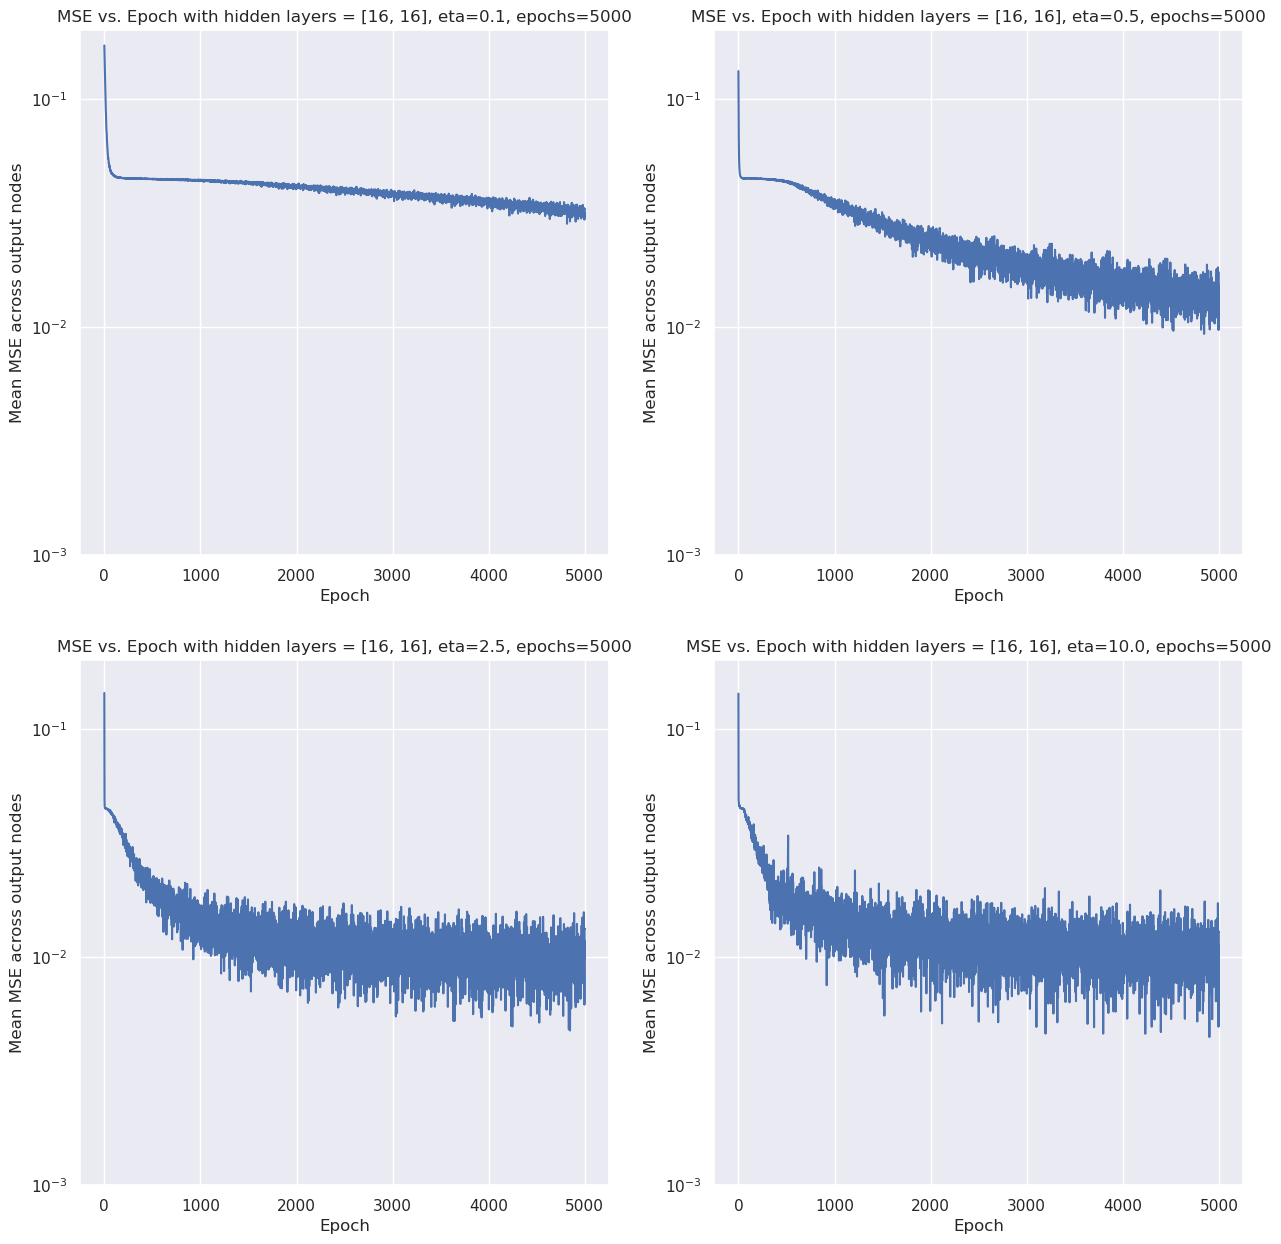

In [26]:
fig, axs = plt.subplots(2, 2, figsize=(15, 15))
# find average error at different layer counts
hidden_layers_1 = [16, 16]
eta_1 = 0.1
epochs_1 = 5000
nn_1 = MultilayerPerceptron(hidden_layers_1, sigmoid, derivative_sigmoid)
errors_1 = nn_1.train(X, y, 10, eta = eta_1, epochs=epochs_1)
mean_errors_1 = np.mean(errors_1, axis=1)
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Mean MSE across output nodes")
axs[0, 0].set_title(f"MSE vs. Epoch with hidden layers = {hidden_layers_1}, eta={eta_1}, epochs={epochs_1}")
axs[0, 0].semilogy(mean_errors_1)
axs[0, 0].set_ylim([1e-3, 2e-1])

hidden_layers_2 = [16, 16]
eta_2 = 0.5
epochs_2 = 5000
nn_2 = MultilayerPerceptron(hidden_layers_2, sigmoid, derivative_sigmoid)
errors_2 = nn_2.train(X, y, 10, eta = eta_2, epochs=epochs_2)
mean_errors_2 = np.mean(errors_2, axis=1)
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Mean MSE across output nodes")
axs[0, 1].set_title(f"MSE vs. Epoch with hidden layers = {hidden_layers_2}, eta={eta_2}, epochs={epochs_2}")
axs[0, 1].semilogy(mean_errors_2)
axs[0, 1].set_ylim([1e-3, 2e-1])

hidden_layers_3 = [16, 16]
eta_3 = 2.5
epochs_3 = 5000
nn_3 = MultilayerPerceptron(hidden_layers_3, sigmoid, derivative_sigmoid)
errors_3 = nn_3.train(X, y, 10, eta = eta_3, epochs=epochs_3)
mean_errors_3 = np.mean(errors_3, axis=1)
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Mean MSE across output nodes")
axs[1, 0].set_title(f"MSE vs. Epoch with hidden layers = {hidden_layers_3}, eta={eta_3}, epochs={epochs_3}")
axs[1, 0].semilogy(mean_errors_3)
axs[1, 0].set_ylim([1e-3, 2e-1])

hidden_layers_4 = [16, 16]
eta_4 = 10.0
epochs_4 = 5000
nn_4 = MultilayerPerceptron(hidden_layers_4, sigmoid, derivative_sigmoid)
errors_4 = nn_4.train(X, y, 10, eta = eta_4, epochs=epochs_4)
mean_errors_4 = np.mean(errors_4, axis=1)
axs[1, 1].set_xlabel("Epoch")
axs[1, 1].set_ylabel("Mean MSE across output nodes")
axs[1, 1].set_title(f"MSE vs. Epoch with hidden layers = {hidden_layers_4}, eta={eta_4}, epochs={epochs_4}")
axs[1, 1].semilogy(mean_errors_4)
axs[1, 1].set_ylim([1e-3, 2e-1])

Now, display failing test items:

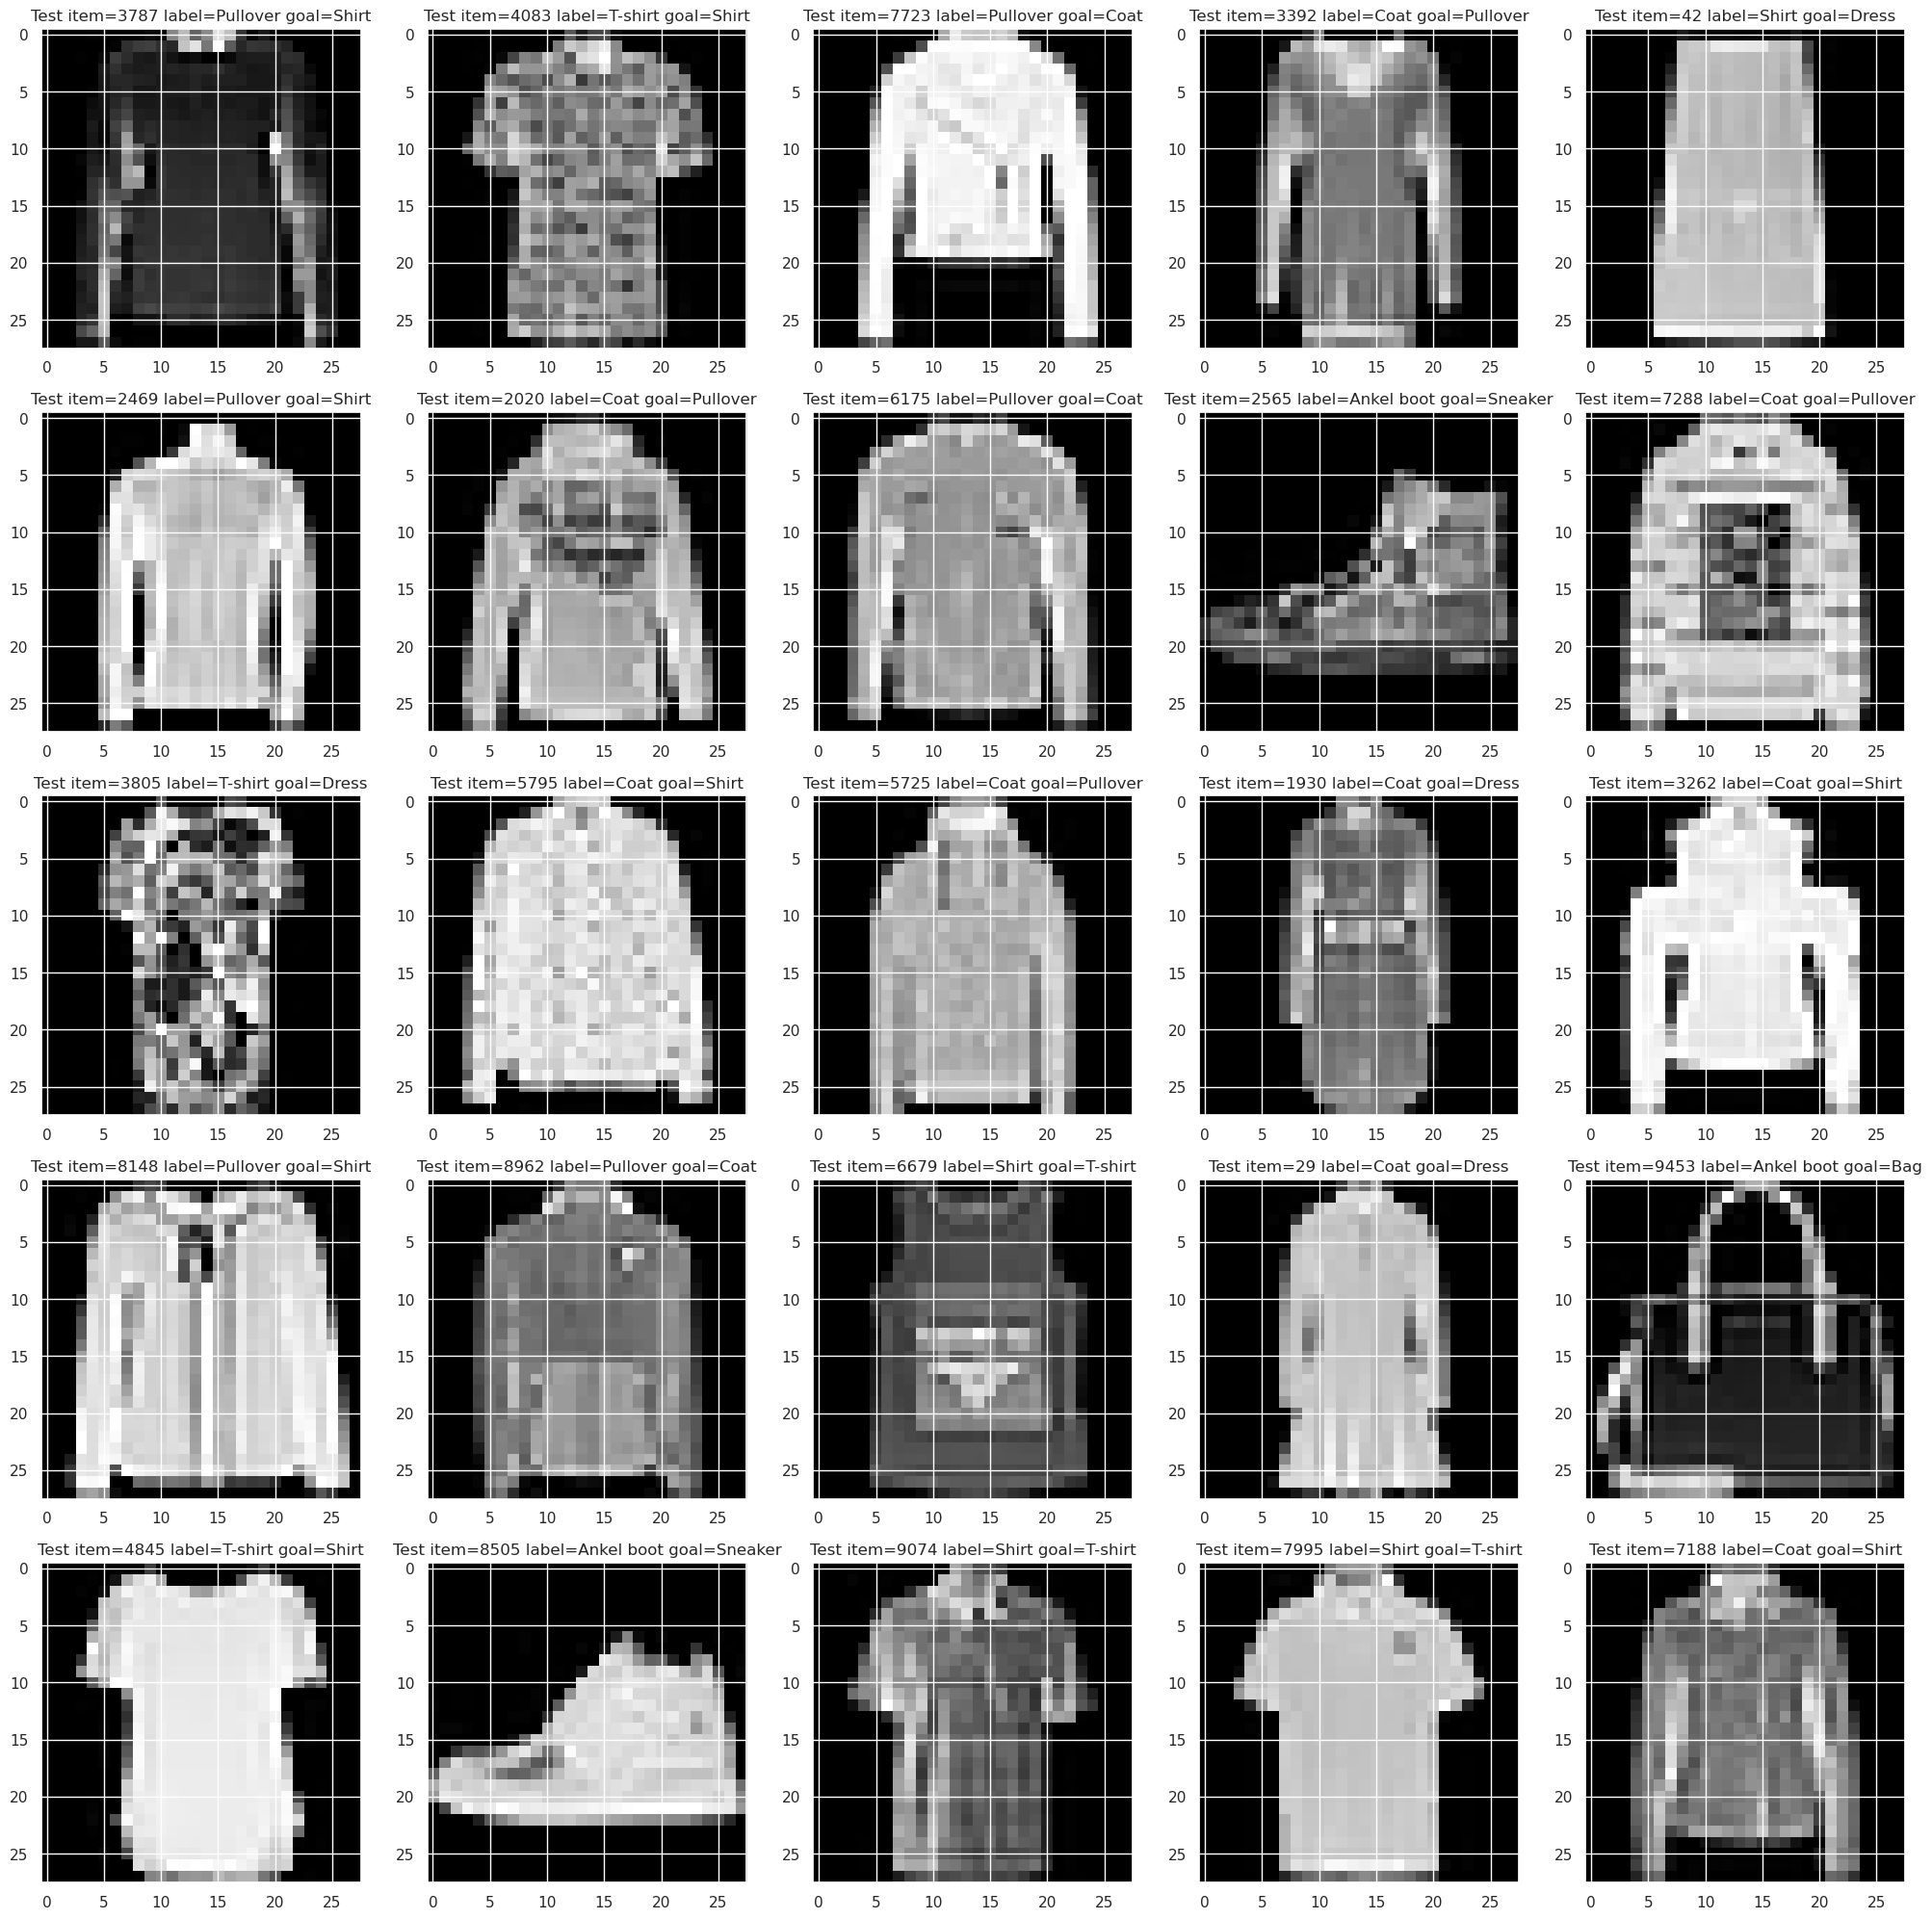

In [27]:
y_hat_test = nn.feed_forward(X_test.reshape(10000, -1))

def display_images(y_hat_test, y_test, n, m, show_mismatch=False):
    y_test_argmax = np.argmax(y_test, axis=1)
    y_hat_test_argmax = np.argmax(y_hat_test, axis=1)
    if show_mismatch:
        results = [i for i in range(len(y_test)) if y_test_argmax[i] != y_hat_test_argmax[i]]
    else:
        results = [i for i in range(len(y_test))]
        # results = [y_data for y_data in np.argmax(y_test, axis=1)]
    
    items = np.array(random.sample(results, k=n*m)).reshape(n, m)
    
    fig, axs = plt.subplots(n, m, figsize = (5*n, 5*m))
    for i in range(n):
        for j in range(m):
            # first pick n by m items from test data:
            item = items[i, j]
            axs[i, j].set_title(f"Test item={item} label={label_to_name_map[y_hat_test_argmax[item]]} goal={label_to_name_map[y_test_argmax[item]]}")
            axs[i, j].imshow(test_images[item, :, :], cmap=plt.cm.gray)

display_images(y_hat_test, y_test, 5, 5, show_mismatch=True)